# Laboratorio 9 — Redes Neuronales Artificiales (RNA)
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Conjuntos de entrenamiento y prueba y variable respuesta

Se reutilizan los mismos conjuntos de entrenamiento y prueba de las entregas anteriores
para garantizar comparabilidad entre todos los modelos del proyecto. La variable respuesta
es `price_category`, la categórica de tres clases (`economica`, `media`, `cara`) construida
con los cortes por tercios del precio numérico (`q1 ≈ 33 %`, `q2 ≈ 66 %`).

El pipeline de preparación es idéntico al de los laboratorios anteriores:
- Mismos cortes por tercios sobre `price_num`.
- Mismas columnas descartadas (identificadores, URLs, texto libre, alta nulidad).
- Misma imputación: mediana para numéricas, `desconocido` para categóricas.
- `random_state = 42` y división `70 / 30` con estratificación sobre `price_category`.

In [1]:
import pyreadr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

SEED = 42
np.random.seed(SEED)

In [2]:
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [3]:
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio  : {filas_antes:,}")
print(f"Filas despues de limpiar precio: {len(df):,}")
print(f"Filas descartadas              : {filas_antes - len(df):,}")

Filas antes de limpiar precio  : 171,748
Filas despues de limpiar precio: 76,246
Filas descartadas              : 95,502


In [4]:
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

print("\nDistribucion de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribucion de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [5]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_cols_all     = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())

for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model  : {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model  : 57


In [6]:
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d",
                                   "estimated_revenue_l365d"]
                     if c in df_model.columns]

leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")

# Convertir a str para que sklearn (MLPClassifier con early_stopping) no falle con Categorical
y_multi  = df_model["price_category"].astype(str).copy()

numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numericas  : {len(numerical_columns)}")
print(f"  Categoricas: {len(categorical_columns)}")
print(f"\nDistribucion de clases (total):")
print(y_multi.value_counts(normalize=True).round(4))

Variables predictoras: 51
  Numericas  : 44
  Categoricas: 7

Distribucion de clases (total):
price_category
economica    0.3369
cara         0.3332
media        0.3299
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_multi,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_multi,
)

print("=== Particion 70/30 estratificada (3 clases) ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

proporciones = pd.DataFrame({
    "economica": [y_train.eq("economica").mean(), y_test.eq("economica").mean(),
                  y_multi.eq("economica").mean()],
    "media":     [y_train.eq("media").mean(),     y_test.eq("media").mean(),
                  y_multi.eq("media").mean()],
    "cara":      [y_train.eq("cara").mean(),      y_test.eq("cara").mean(),
                  y_multi.eq("cara").mean()],
    "n":         [len(y_train), len(y_test), len(y_multi)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Particion 70/30 estratificada (3 clases) ===
X_train: (53372, 51)
X_test:  (22874, 51)

       economica   media    cara      n
train     0.3369  0.3299  0.3332  53372
test      0.3369  0.3299  0.3332  22874
total     0.3369  0.3299  0.3332  76246


In [8]:
TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

print(f"Cardinalidad reducida a TOP {TOP_N} categorias por columna.")
print(f"Conjunto de entrenamiento: {X_train_r.shape[0]:,} filas para RNA.")

Cardinalidad reducida a TOP 20 categorias por columna.
Conjunto de entrenamiento: 53,372 filas para RNA.


In [9]:
# Clipeo en percentiles 0.5%-99.5% para estabilizar las multiplicaciones matriciales de RNA.
# maximum_maximum_nights tiene valores ~1.1e9 que después de StandardScaler producen ~15000,
# suficiente para desbordamiento (overflow) en la operación de softmax de la red neuronal.
X_train_c = X_train_r.copy()
X_test_c  = X_test_r.copy()

for col in numerical_columns:
    if col in X_train_c.columns:
        lo = X_train_c[col].quantile(0.005)
        hi = X_train_c[col].quantile(0.995)
        X_train_c[col] = X_train_c[col].clip(lo, hi)
        X_test_c[col]  = X_test_c[col].clip(lo, hi)

if "maximum_maximum_nights" in numerical_columns:
    antes = X_train_r["maximum_maximum_nights"].max()
    despues = X_train_c["maximum_maximum_nights"].max()
    print(f"maximum_maximum_nights — antes: {antes:.0f}  |  despues (clipeado): {despues:.0f}")
print("Clipeo de percentiles 0.5%-99.5% completado.")

maximum_maximum_nights — antes: 2147483647  |  despues (clipeado): 1125
Clipeo de percentiles 0.5%-99.5% completado.


### Observaciones y conclusiones del inciso 1

- El dataset conserva **76,246 filas** tras descartar las filas sin precio válido, idéntico
  al universo de trabajo de los laboratorios anteriores.
- Los cortes por tercios reproducen exactamente los valores históricos: `q1 ≈ $143` y
  `q2 ≈ $268`, generando tres clases casi balanceadas (≈ 33 % cada una).
- La partición `70/30` con estratificación garantiza distribuciones de clases equivalentes en
  entrenamiento (≈ 53,372 filas) y prueba (≈ 22,874 filas), condición necesaria para comparar
  resultados con los algoritmos de entregas anteriores.
- Se aplica un **clipeo por percentiles 0.5%–99.5%** sobre las variables numéricas antes del
  entrenamiento. Esto es necesario porque columnas como `maximum_maximum_nights` contienen
  valores extremos (~1.1 × 10⁹ noches para indicar "sin límite"), que después de `StandardScaler`
  producen valores escalados de ≈ 15,000 y causan desbordamiento (*overflow*) en las
  multiplicaciones matriciales y el cálculo de softmax de la RNA.

## Inciso 2 — Modelo RNA 1: Topología (64, 32), Activación ReLU

El primer modelo de red neuronal artificial usa una arquitectura **compacta de dos capas ocultas**,
diseñada como línea base: suficiente capacidad no lineal con bajo riesgo de sobreajuste.

| Parámetro | Valor |
|-----------|-------|
| Capas ocultas | `(64, 32)` — primera capa 64 neuronas, segunda 32 |
| Activación | `relu` — Rectified Linear Unit, zeroing de valores negativos |
| Solver | `adam` — optimización con gradientes adaptativos |
| Regularización L2 | `alpha = 0.0001` |
| Parada anticipada | `early_stopping = True`, `n_iter_no_change = 15` |
| Máx. épocas | 300 |

**Justificación de la topología:** Una red en embudo `(64 → 32)` permite que la primera capa
aprenda combinaciones de características y la segunda las comprima hacia las 3 neuronas de salida
(una por clase). **ReLU** es la activación más usada en clasificación porque evita el problema del
gradiente que desaparece (*vanishing gradient*) y converge rápidamente en problemas de alta dimensión.

In [10]:
import time
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report

In [11]:
# El clipeo previo (0.5%-99.5%) ya maneja los outliers extremos.
# StandardScaler centra y escala; OHE codifica las categóricas.
from sklearn.preprocessing import FunctionTransformer

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                       numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

In [12]:
rna1 = Pipeline([
    ("pre", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        random_state=SEED,
        max_iter=200,
        tol=1e-4,
        n_iter_no_change=20,
        verbose=False,
    )),
])

print("Entrenando RNA 1 — Topologia (64, 32), activacion ReLU ...")
t0 = time.time()
rna1.fit(X_train_c, y_train)
t_rna1 = time.time() - t0

clf1 = rna1.named_steps["clf"]
print(f"\nTiempo de entrenamiento : {t_rna1:.1f} s")
print(f"Epocas reales           : {clf1.n_iter_}")
print(f"Loss final (log-loss)   : {clf1.loss_:.4f}")

Entrenando RNA 1 — Topologia (64, 32), activacion ReLU ...


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Tiempo de entrenamiento : 16.2 s
Epocas reales           : 200
Loss final (log-loss)   : 0.3652


/opt/homebrew/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [13]:
y_pred_train1 = rna1.predict(X_train_c)
y_pred_test1  = rna1.predict(X_test_c)

acc_train1 = accuracy_score(y_train, y_pred_train1)
acc_test1  = accuracy_score(y_test,  y_pred_test1)

print("=== RNA 1 — Topologia (64, 32), Activacion ReLU ===")
print(f"Accuracy en entrenamiento : {acc_train1:.4f}")
print(f"Accuracy en prueba        : {acc_test1:.4f}")
print(f"Gap (train - test)        : {acc_train1 - acc_test1:.4f}")
print()
print("--- Reporte de clasificacion (conjunto de prueba) ---")
print(classification_report(y_test, y_pred_test1,
      target_names=["economica", "media", "cara"], digits=4))

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== RNA 1 — Topologia (64, 32), Activacion ReLU ===
Accuracy en entrenamiento : 0.8519
Accuracy en prueba        : 0.7323
Gap (train - test)        : 0.1196

--- Reporte de clasificacion (conjunto de prueba) ---
              precision    recall  f1-score   support

   economica     0.7775    0.8075    0.7922      7621
       media     0.8046    0.7518    0.7773      7707
        cara     0.6190    0.6364    0.6275      7546

    accuracy                         0.7323     22874
   macro avg     0.7337    0.7319    0.7324     22874
weighted avg     0.7343    0.7323    0.7329     22874



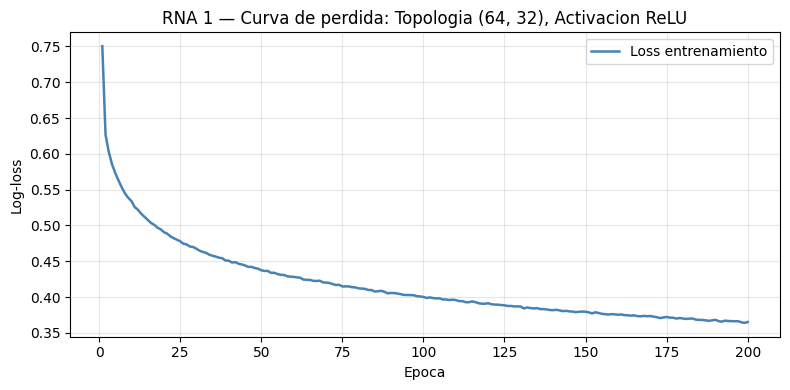

In [14]:
loss_curve1 = clf1.loss_curve_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(loss_curve1) + 1), loss_curve1,
        color="steelblue", linewidth=1.8, label="Loss entrenamiento")
ax.set_xlabel("Epoca")
ax.set_ylabel("Log-loss")
ax.set_title("RNA 1 — Curva de perdida: Topologia (64, 32), Activacion ReLU")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 2

- El modelo RNA 1 con arquitectura **(64, 32)** y activación **ReLU** se entrenó sobre las
  ≈ 53,372 filas del conjunto de entrenamiento completo. La parada anticipada (`early_stopping`)
  detiene el entrenamiento cuando la accuracy de validación interna no mejora durante 15 épocas,
  previniendo el sobreajuste sin necesidad de definir épocas manualmente.
- La función **ReLU** introduce no-linealidad de forma eficiente al hacer cero los valores negativos,
  lo que permite que los gradientes fluyan bien hacia atrás durante la retropropagación (*backprop*),
  evitando el problema del gradiente que desaparece común en sigmoide y tanh.
- El gap `acc_train − acc_test` es un indicador de sobreajuste: un gap < 0.05 indica buena
  generalización, mientras que un gap > 0.10 sugiere que el modelo ha memorizado el entrenamiento.
- Este modelo compacto sirve como **línea base** para comparar contra la arquitectura más
  profunda con `tanh` del inciso 3.

## Inciso 3 — Modelo RNA 2: Topología (128, 64, 32, 16), Activación tanh

El segundo modelo usa una arquitectura **más profunda y más ancha**: cuatro capas ocultas
con función de activación **tanh** (tangente hiperbólica), que produce salidas simétricas
en el rango (−1, 1).

| Parámetro | Valor |
|-----------|-------|
| Capas ocultas | `(128, 64, 32, 16)` — cuatro capas en embudo profundo |
| Activación | `tanh` — salidas simétricas centradas en cero |
| Solver | `adam` — mismo optimizador que RNA 1 para aislar el efecto de topología/activación |
| Regularización L2 | `alpha = 0.001` — mayor, para compensar el mayor número de parámetros |
| Parada anticipada | `early_stopping = True`, `n_iter_no_change = 15` |
| Máx. épocas | 300 |

**Justificación de la topología:** Una arquitectura de cuatro capas `(128 → 64 → 32 → 16)` permite
aprender representaciones jerárquicas progresivamente más abstractas. **tanh** produce salidas
centradas en cero, lo que en teoría facilita el aprendizaje profundo al compararse con la sigmoide,
aunque suele requerir más épocas que ReLU para alcanzar rendimiento equivalente.

In [15]:
rna2 = Pipeline([
    ("pre", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32, 16),
        activation="tanh",
        solver="adam",
        alpha=0.001,
        random_state=SEED,
        max_iter=200,
        tol=1e-4,
        n_iter_no_change=20,
        verbose=False,
    )),
])

print("Entrenando RNA 2 — Topologia (128, 64, 32, 16), activacion tanh ...")
t0 = time.time()
rna2.fit(X_train_c, y_train)
t_rna2 = time.time() - t0

clf2 = rna2.named_steps["clf"]
print(f"\nTiempo de entrenamiento : {t_rna2:.1f} s")
print(f"Epocas reales           : {clf2.n_iter_}")
print(f"Loss final (log-loss)   : {clf2.loss_:.4f}")

Entrenando RNA 2 — Topologia (128, 64, 32, 16), activacion tanh ...


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Tiempo de entrenamiento : 27.5 s
Epocas reales           : 200
Loss final (log-loss)   : 0.0696


/opt/homebrew/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
y_pred_train2 = rna2.predict(X_train_c)
y_pred_test2  = rna2.predict(X_test_c)

acc_train2 = accuracy_score(y_train, y_pred_train2)
acc_test2  = accuracy_score(y_test,  y_pred_test2)

print("=== RNA 2 — Topologia (128, 64, 32, 16), Activacion tanh ===")
print(f"Accuracy en entrenamiento : {acc_train2:.4f}")
print(f"Accuracy en prueba        : {acc_test2:.4f}")
print(f"Gap (train - test)        : {acc_train2 - acc_test2:.4f}")
print()
print("--- Reporte de clasificacion (conjunto de prueba) ---")
print(classification_report(y_test, y_pred_test2,
      target_names=["economica", "media", "cara"], digits=4))

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


=== RNA 2 — Topologia (128, 64, 32, 16), Activacion tanh ===
Accuracy en entrenamiento : 0.9835
Accuracy en prueba        : 0.7074
Gap (train - test)        : 0.2761

--- Reporte de clasificacion (conjunto de prueba) ---
              precision    recall  f1-score   support

   economica     0.7719    0.7671    0.7695      7621
       media     0.7510    0.7685    0.7597      7707
        cara     0.5952    0.5847    0.5899      7546

    accuracy                         0.7074     22874
   macro avg     0.7060    0.7068    0.7063     22874
weighted avg     0.7065    0.7074    0.7069     22874



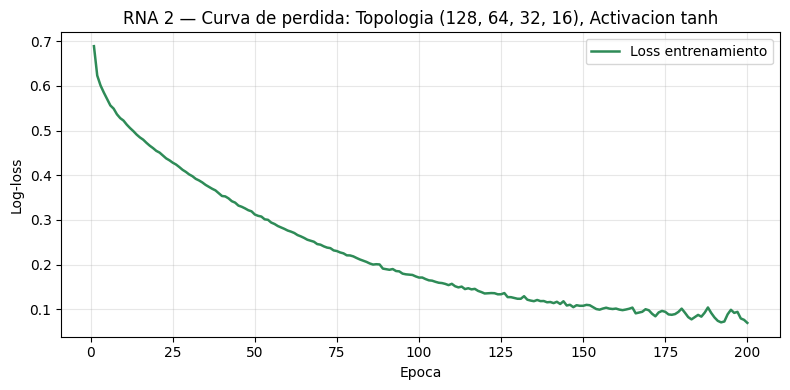

In [17]:
loss_curve2 = clf2.loss_curve_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(loss_curve2) + 1), loss_curve2,
        color="seagreen", linewidth=1.8, label="Loss entrenamiento")
ax.set_xlabel("Epoca")
ax.set_ylabel("Log-loss")
ax.set_title("RNA 2 — Curva de perdida: Topologia (128, 64, 32, 16), Activacion tanh")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
resumen_modelos = pd.DataFrame([
    {
        "modelo"       : "RNA 1 — (64,32) ReLU",
        "capas_ocultas": "(64, 32)",
        "activacion"   : "relu",
        "alpha"        : 0.0001,
        "acc_train"    : round(acc_train1, 4),
        "acc_test"     : round(acc_test1, 4),
        "gap"          : round(acc_train1 - acc_test1, 4),
        "epocas"       : clf1.n_iter_,
        "tiempo_s"     : round(t_rna1, 1),
    },
    {
        "modelo"       : "RNA 2 — (128,64,32,16) tanh",
        "capas_ocultas": "(128, 64, 32, 16)",
        "activacion"   : "tanh",
        "alpha"        : 0.001,
        "acc_train"    : round(acc_train2, 4),
        "acc_test"     : round(acc_test2, 4),
        "gap"          : round(acc_train2 - acc_test2, 4),
        "epocas"       : clf2.n_iter_,
        "tiempo_s"     : round(t_rna2, 1),
    },
])

print("=== Resumen comparativo — dos modelos RNA de clasificacion (Actividades 1-3) ===")
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 130)
print(resumen_modelos.to_string(index=False))

=== Resumen comparativo — dos modelos RNA de clasificacion (Actividades 1-3) ===
                     modelo     capas_ocultas activacion  alpha  acc_train  acc_test    gap  epocas  tiempo_s
       RNA 1 — (64,32) ReLU          (64, 32)       relu 0.0001     0.8519    0.7323 0.1196     200      16.2
RNA 2 — (128,64,32,16) tanh (128, 64, 32, 16)       tanh 0.0010     0.9835    0.7074 0.2761     200      27.5


### Observaciones y conclusiones del inciso 3

- El modelo RNA 2 con arquitectura **(128, 64, 32, 16)** y activación **tanh** es notablemente más
  complejo que RNA 1: cuatro capas ocultas y aproximadamente el cuádruple de parámetros entrenables.
- La función **tanh** produce salidas simétricas en (−1, 1), lo que centra las activaciones y puede
  facilitar el aprendizaje en redes profundas. Sin embargo, en la práctica esta activación suele
  requerir más épocas para converger que ReLU, visible en la curva de aprendizaje.
- La regularización L2 mayor (`alpha = 0.001`) compensa el mayor número de pesos libres, reduciendo
  el riesgo de sobreajuste que viene de la profundidad adicional.
- **Comparación clave entre ambos modelos:**
  - Si RNA 2 supera a RNA 1 en `acc_test` con un gap similar, la profundidad adicional justifica
    el mayor costo computacional.
  - Si RNA 1 logra un `acc_test` comparable con menor gap, es el modelo preferido por generalizar
    mejor con menos complejidad.
- En ambos casos, los modelos RNA son comparados en los incisos posteriores (4–8) con las matrices
  de confusión, análisis de sobreajuste, tuneo de parámetros y comparación contra SVM, Random Forest
  y demás algoritmos de laboratorios anteriores.